# 1. Combining + Visualizing

In [17]:
import csv
from pathlib import Path
import pandas as pd
import numpy as np

BASE = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Google Trends Data + Extracter").exists())
GT   = BASE / "Google Trends Data + Extracter"
RAW  = GT / "raw"
PLAN = GT / "trends_pull_urls.csv"

assert PLAN.exists(), f"plan not found at {PLAN}"
print(f"{len(list(RAW.glob('*.csv')))} files in raw/")     # 68

STATES = [
 "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut",
 "Delaware","District of Columbia","Florida","Georgia","Hawaii","Idaho","Illinois",
 "Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts",
 "Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska","Nevada",
 "New Hampshire","New Jersey","New Mexico","New York","North Carolina","North Dakota",
 "Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island","South Carolina",
 "South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington",
 "West Virginia","Wisconsin","Wyoming"]

68 files in raw/


Helper Function to describe stats

In [18]:
def describe_stats(df, cols=None, label=""):
    """Descriptive stats table: n, missing, mean, median, mode, sd, min/max, skew, kurtosis."""
    num = df[cols] if cols else df.select_dtypes("number")
    rows = {}
    for c in num.columns:
        s = num[c].dropna()
        # mode on continuous data: round first, else every value is its own mode
        m = s.round(1).mode()
        rows[c] = {
            "n":        int(s.size),
            "missing":  int(num[c].isna().sum()),
            "mean":     s.mean(),
            "median":   s.median(),
            "mode":     m.iloc[0] if len(m) else np.nan,
            "mode_n":   int((s.round(1) == m.iloc[0]).sum()) if len(m) else 0,
            "sd":       s.std(),
            "min":      s.min(),
            "max":      s.max(),
            "skew":     s.skew(),      # Fisher-Pearson, 0 = symmetric
            "kurtosis": s.kurtosis(),  # excess, 0 = normal
        }
    out = pd.DataFrame(rows).T.round(3)
    if label:
        print(f"--- {label} (n rows = {len(df)}) ---")
    return out

Takes one Google Trends "Interest by subregion" CSV and returns a clean pandas Series of 51 state values.

Essentially:
Messy CSV → find the header → parse rows → clean values → align to 51 states

In [19]:
def read_geomap(path):
    """One Trends 'Interest by subregion' CSV -> Series indexed by the 51 states."""
    lines = [l for l in Path(path).read_text(encoding="utf-8-sig").splitlines() if l.strip()]
    h = next((i for i, l in enumerate(lines)
              if l.split(",")[0].strip() in ("Region", "Country")), None)
    if h is None:
        raise ValueError(f"{Path(path).name}: no 'Region' header — Interest-over-time file?")

    rows = list(csv.reader(lines[h:]))
    header, body = rows[0], [r for r in rows[1:] if r and r[0].strip()]
    if len(header) - 1 > 1:
        raise ValueError(f"{Path(path).name}: compared breakdown (rows sum to 100%), "
                         "not a single-term export")

    def num(x):
        x = x.strip().replace("%", "")
        if x in ("", "N/A"):  return np.nan
        if x.startswith("<"): return 0.5          # Trends' "<1"
        try:    return float(x)
        except ValueError: return np.nan

    return pd.Series({r[0].strip(): num(r[1]) for r in body},
                     dtype=float).reindex(STATES)

Loads all 68 Trends CSVs, stacks them into one long table, then reshapes to one row per state-year.

In [20]:
plan = pd.read_csv(PLAN)

recs = []
for r in plan.itertuples():
    s = read_geomap(RAW / r.save_as)
    recs.append(pd.DataFrame({"state": s.index, "year": r.year,
                              "category": r.category, "term_id": r.term_id,
                              "term": r.term, "rsv": s.values}))
long = pd.concat(recs, ignore_index=True)      # keep this — z-scoring is easier long

col_order = (plan.sort_values(["category", "order"])
                 .drop_duplicates("term_id").term_id.tolist())

wide = (long.pivot_table(index=["state", "year"], columns="term_id", values="rsv")
            .reindex(columns=col_order)
            .reset_index()
            .sort_values(["state", "year"]))
wide.columns.name = None

print(wide.shape)          # (204, 19)
wide.head()

(204, 19)


,state,year,polling_place,where_to_vote,register_to_vote,sample_ballot,how_to_vote,us_pres_election,year_election,election_day,presidential_debate,electoral_college,absentee_ballot,early_voting,vote_by_mail,voter_id,ballot_drop_box,nominee_dem,nominee_rep
0,Alabama,2012,31.0,61.0,79.0,68.0,100.0,91.0,88.0,56.0,48.0,92.0,78.0,19.0,NaN,15.0,NaN,81.0,59.0
1,Alabama,2016,46.0,53.0,70.0,46.0,74.0,61.0,73.0,50.0,64.0,82.0,64.0,14.0,4.0,53.0,NaN,71.0,77.0
2,Alabama,2020,49.0,51.0,66.0,82.0,92.0,67.0,72.0,42.0,65.0,45.0,75.0,24.0,28.0,40.0,4.0,61.0,74.0
3,Alabama,2024,40.0,88.0,81.0,34.0,100.0,43.0,67.0,57.0,52.0,53.0,49.0,21.0,14.0,61.0,NaN,51.0,75.0
4,Alaska,2012,25.0,31.0,34.0,10.0,38.0,87.0,76.0,45.0,69.0,76.0,43.0,20.0,NaN,14.0,NaN,52.0,45.0


Raw Trends RSV

In [21]:
# per-term RSV distribution across the 51 states
print(describe_stats(wide, cols=col_order, label="Google Trends RSV by term").to_string())

# same thing pooled, split by year — checks whether a year is scaled differently
print("\nRSV pooled by year:")
print(long.groupby("year")["rsv"]
          .agg(n="count", mean="mean", median="median", sd="std", skew="skew")
          .round(3).to_string())

--- Google Trends RSV by term (n rows = 204) ---
                         n  missing    mean  median  mode  mode_n      sd   min    max   skew  kurtosis
polling_place        202.0      2.0  38.010    32.0  25.0    10.0  21.397   7.0  100.0  1.039     0.544
where_to_vote        204.0      0.0  57.515    56.0  45.0    11.0  17.447  16.0  100.0  0.277    -0.191
register_to_vote     204.0      0.0  66.044    66.0  64.0    10.0  13.234  33.0  100.0  0.208    -0.013
sample_ballot        203.0      1.0  24.690    20.0  15.0    11.0  19.764   1.0  100.0  1.800     3.942
how_to_vote          204.0      0.0  77.882    79.0  86.0    12.0  12.230  38.0  100.0 -0.481     0.058
us_pres_election     204.0      0.0  71.814    73.0  64.0     9.0  14.772  41.0  100.0 -0.112    -0.875
year_election        204.0      0.0  73.941    73.0  72.0    13.0   8.743  44.0  100.0  0.422     0.929
election_day         204.0      0.0  63.907    62.0  57.0    14.0  11.324  39.0  100.0  1.006     1.281
presidential_de

Output file (comment out if not needed)

In [22]:
# OUT = GT / "out"
# OUT.mkdir(exist_ok=True)
# XLSX = OUT / "trends_combined.xlsx"

# # lookup sheet: which category / search string / form each column came from
# key = (plan.drop_duplicates("term_id")[["category", "term_id", "term", "form"]]
#            .set_index("term_id").reindex(col_order).reset_index())

# with pd.ExcelWriter(XLSX, engine="openpyxl") as xl:
#     wide.to_excel(xl, sheet_name="wide",     index=False, freeze_panes=(1, 2))
#     long.to_excel(xl, sheet_name="long",     index=False, freeze_panes=(1, 0))
#     key .to_excel(xl, sheet_name="term_key", index=False)

#     # readable column widths
#     for sheet, df in [("wide", wide), ("long", long), ("term_key", key)]:
#         ws = xl.sheets[sheet]
#         for i, c in enumerate(df.columns, 1):
#             w = max(len(str(c)), int(df[c].astype(str).str.len().max() or 0))
#             ws.column_dimensions[ws.cell(1, i).column_letter].width = min(max(w + 2, 9), 40)

# print(f"wrote {XLSX}  ({XLSX.stat().st_size/1024:.0f} KB)")

In [23]:
print(wide.groupby("year").size())                    # 51 each
print(wide.isna().sum()[lambda s: s > 0])             # where Google returned nothing

year
2012    51
2016    51
2020    51
2024    51
dtype: int64
polling_place        2
sample_ballot        1
vote_by_mail        25
voter_id            11
ballot_drop_box    104
dtype: int64


Dependent Vars

In [24]:
TURN = BASE / "Official Turnout Data"
PE   = TURN / "Presidential Elections"

PRES_FILES = {2008: "Turnout_2008G_v1.2.csv",
              2012: "Turnout_2012G_v1.0.csv",
              2016: "Turnout_2016G_v1.0.csv",
              2020: "Turnout_2020G_v1.2.csv",
              2024: "Turnout_2024G_v0.4.csv"}

def num(s):
    """'2,105,622' / '60.94%' -> float."""
    return pd.to_numeric(s.astype(str).str.replace(r"[,%]", "", regex=True).str.strip(),
                         errors="coerce")

def read_vep(path, year):
    """Election Lab turnout file -> state / year / VEP turnout rate."""
    d = pd.read_csv(path)
    d.columns = [c.strip().upper() for c in d.columns]
    d["state"]   = d.STATE.astype(str).str.strip().str.replace(r"\*+$", "", regex=True)
    d["turnout"] = num(d.VEP_TURNOUT_RATE)

    # 2008: CT, MS and TX reported no total-ballots count, so the source leaves
    # VEP_TURNOUT_RATE blank. Fall back to the highest-office rate (~0.5pp lower).
    if "VOTE_FOR_HIGHEST_OFFICE" in d.columns:
        d["turnout"] = d.turnout.fillna(100 * num(d.VOTE_FOR_HIGHEST_OFFICE) / num(d.VEP))

    d["year"] = year
    return d.loc[d.state.isin(STATES), ["state", "year", "turnout"]]

hist = (pd.concat([read_vep(PE / f, y) for y, f in PRES_FILES.items()], ignore_index=True)
          .sort_values(["state", "year"]).reset_index(drop=True))
hist["turnout_prev"] = hist.groupby("state")["turnout"].shift(1)
target = hist[hist.year >= 2012].reset_index(drop=True)

assert len(hist) == 51 * len(PRES_FILES), f"duplicate or missing rows: {len(hist)}"
assert len(target) == 204 and target.turnout.notna().all()
assert target.turnout_prev.notna().all(), "missing lag"
print("target:", target.shape, "| rows/yr:", target.groupby("year").size().to_dict())

target: (204, 4) | rows/yr: {2012: 51, 2016: 51, 2020: 51, 2024: 51}


Creating categories

In [25]:
DROP      = ["us_pres_election", "ballot_drop_box", "vote_by_mail"]
MIN_TERMS = 2

# Theory-driven constructs (defined 2026-09-19, before any new terms are pulled).
# A/B split candidate-centred from institution-centred attention; C/D split the
# cost of figuring out HOW to vote from the availability of voting MODES.
REGROUP = {
    "nominee_dem": "A_candidate", "nominee_rep": "A_candidate",
    "presidential_debate": "A_candidate",

    "year_election": "B_salience", "election_day": "B_salience",
    "electoral_college": "B_salience",

    "how_to_vote": "C_friction", "where_to_vote": "C_friction",
    "polling_place": "C_friction", "sample_ballot": "C_friction",
    "voter_id": "C_friction",

    "absentee_ballot": "D_access", "early_voting": "D_access",
    "register_to_vote": "D_access",
}

SAMPLE = target.dropna(subset=["turnout", "turnout_prev"])[["state", "year"]]

d = (long[~long.term_id.isin(DROP)]
       .merge(SAMPLE, on=["state", "year"], how="inner")
       .copy())
d["category"] = d.term_id.map(REGROUP)          # <- overrides the plan file's grouping
assert d.category.notna().all(), d.loc[d.category.isna(), "term_id"].unique()
d["rsv"] = d.rsv.fillna(0)

g = d.groupby(["term_id", "year"])["rsv"]
d["z"] = (d.rsv - g.transform("mean")) / g.transform("std")

agg = d.groupby(["state", "year", "category"])["z"].agg(["mean", "count"])
agg.loc[agg["count"] < MIN_TERMS, "mean"] = np.nan

cats = agg["mean"].unstack("category").reset_index()
cats.columns.name = None
cats = cats.rename(columns={"A_candidate": "candidate_index",
                            "B_salience":  "salience_index",
                            "C_friction":  "friction_index",
                            "D_access":    "access_index"})
print(cats.shape)

(204, 6)


In [28]:
TRENDS = ["candidate_index", "salience_index", "friction_index", "access_index"]
FEATS  = ["turnout_prev"] + TRENDS

panel = target.merge(cats, on=["state", "year"], how="inner")
model_df = panel.dropna(subset=["turnout"] + FEATS).reset_index(drop=True)

print("usable rows by year:")
print(model_df.groupby("year").size().to_string())
print("\nper-year index means (must be ~0.000 in EVERY row):")
print(model_df.groupby("year")[TRENDS].mean().round(4).to_string())

usable rows by year:
year
2012    51
2016    51
2020    51
2024    51

per-year index means (must be ~0.000 in EVERY row):
      candidate_index  salience_index  friction_index  access_index
year                                                               
2012              0.0            -0.0             0.0          -0.0
2016              0.0            -0.0            -0.0           0.0
2020             -0.0             0.0             0.0           0.0
2024             -0.0             0.0             0.0          -0.0


# 2. Testing Variable Strength

In [29]:
panel = (target.merge(cats, on=["state", "year"], how="inner")
               .sort_values(["state", "year"])
               .reset_index(drop=True))

TRENDS = ["candidate_index", "salience_index", "friction_index", "access_index"]
FEATS  = ["turnout_prev"] + TRENDS

model_df = panel.dropna(subset=["turnout"] + FEATS).reset_index(drop=True)

print("usable rows:", len(model_df))                 # 201 now, 204 once 2008 is added
print(model_df.groupby("year").size().to_string())   # 2012 is 48 until then

print("\nper-year index means (must be ~0.0000 in every row):")
print(model_df.groupby("year")[TRENDS].mean().round(4).to_string())
assert model_df.groupby("year")[TRENDS].mean().abs().max().max() < 1e-9

usable rows: 204
year
2012    51
2016    51
2020    51
2024    51

per-year index means (must be ~0.0000 in every row):
      candidate_index  salience_index  friction_index  access_index
year                                                               
2012              0.0            -0.0             0.0          -0.0
2016              0.0            -0.0            -0.0           0.0
2020             -0.0             0.0             0.0           0.0
2024             -0.0             0.0             0.0          -0.0


Indices + turnout descriptive statistics

In [30]:
print(describe_stats(model_df, cols=["turnout", "turnout_prev"] + TRENDS,
                     label="Modelling panel").to_string())

# turnout by election year
print("\nturnout (%) by year:")
print(model_df.groupby("year")["turnout"]
              .agg(n="count", mean="mean", median="median", sd="std",
                   min="min", max="max", skew="skew")
              .round(2).to_string())

--- Modelling panel (n rows = 204) ---
                     n  missing    mean  median  mode  mode_n     sd     min     max   skew  kurtosis
turnout          204.0      0.0  63.615  64.110  64.7     5.0  6.689  43.190  79.210 -0.230    -0.059
turnout_prev     204.0      0.0  63.243  63.650  63.1     4.0  6.568  43.190  79.210 -0.229     0.041
candidate_index  204.0      0.0  -0.000  -0.056   0.2    13.0  0.723  -1.868   2.408  0.481     0.548
salience_index   204.0      0.0  -0.000  -0.035  -0.1    17.0  0.744  -2.370   3.724  0.909     4.023
friction_index   204.0      0.0   0.000   0.009   0.3    17.0  0.611  -1.716   2.239 -0.084     0.605
access_index     204.0      0.0   0.000   0.016  -0.0    20.0  0.587  -1.594   1.609 -0.182     0.149

turnout (%) by year:
       n   mean  median    sd    min    max  skew
year                                             
2012  51  60.51   60.52  6.60  44.36  76.50 -0.04
2016  51  61.65   61.56  6.25  43.19  74.67 -0.33
2020  51  67.05   67.08  

In [31]:
corr = model_df[["turnout"] + FEATS].corr()

print("raw correlation with turnout:")
print(corr["turnout"].drop("turnout").sort_values(ascending=False).round(3).to_string())

print("\ncorrelations between predictors:")
print(corr.loc[FEATS, FEATS].round(2).to_string())

raw correlation with turnout:
turnout_prev       0.824
candidate_index    0.491
salience_index     0.168
access_index       0.077
friction_index    -0.049

correlations between predictors:
                 turnout_prev  candidate_index  salience_index  friction_index  access_index
turnout_prev             1.00             0.44            0.13           -0.04          0.05
candidate_index          0.44             1.00            0.48           -0.01          0.25
salience_index           0.13             0.48            1.00            0.03          0.18
friction_index          -0.04            -0.01            0.03            1.00          0.48
access_index             0.05             0.25            0.18            0.48          1.00


In [32]:
def residualise(x, ctrl):
    """Remove the linear effect of ctrl from x."""
    X = np.column_stack([np.ones(len(ctrl)), ctrl])
    b, *_ = np.linalg.lstsq(X, x, rcond=None)
    return x - X @ b

def partial_corr(df, xcol, ycol, ctrl_cols):
    C = df[ctrl_cols].values
    rx = residualise(df[xcol].values, C)
    ry = residualise(df[ycol].values, C)
    return np.corrcoef(rx, ry)[0, 1]

print(f"{'index':<20}{'raw r':>9}{'partial r':>12}")
for f in TRENDS:
    raw = model_df[f].corr(model_df.turnout)
    par = partial_corr(model_df, f, "turnout", ["turnout_prev"])
    print(f"{f:<20}{raw:>9.3f}{par:>12.3f}")

index                   raw r   partial r
candidate_index         0.491       0.255
salience_index          0.168       0.106
friction_index         -0.049      -0.027
access_index            0.077       0.065


In [33]:
print(f"{'index':<20}" + "".join(f"{y:>9}" for y in sorted(model_df.year.unique())))
for f in TRENDS:
    cells = []
    for y in sorted(model_df.year.unique()):
        g = model_df[model_df.year == y]
        cells.append(partial_corr(g, f, "turnout", ["turnout_prev"]) if len(g) > 5 else np.nan)
    print(f"{f:<20}" + "".join(f"{c:>9.2f}" for c in cells))

index                    2012     2016     2020     2024
candidate_index          0.34     0.43     0.21     0.40
salience_index           0.15     0.24     0.32    -0.04
friction_index           0.13    -0.23    -0.37     0.31
access_index             0.34    -0.09    -0.24     0.47


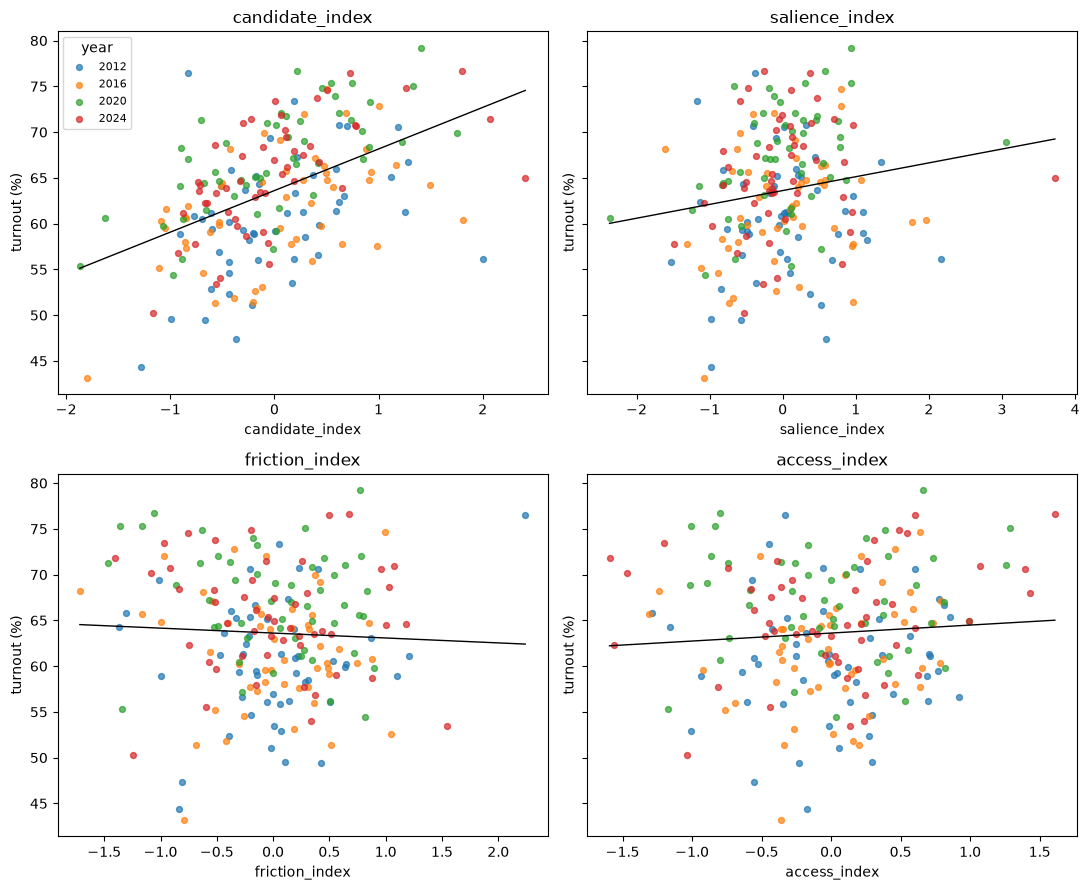

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
for ax, f in zip(axes.ravel(), TRENDS):
    for y, g in model_df.groupby("year"):
        ax.scatter(g[f], g.turnout, s=18, alpha=.7, label=str(y))
    b = np.polyfit(model_df[f], model_df.turnout, 1)
    xs = np.linspace(model_df[f].min(), model_df[f].max(), 50)
    ax.plot(xs, np.polyval(b, xs), color="black", lw=1)
    ax.set_xlabel(f); ax.set_ylabel("turnout (%)"); ax.set_title(f)
axes[0, 0].legend(title="year", fontsize=8)
plt.tight_layout(); plt.show()

In [35]:
def fit_ols(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return b

def predict(b, X):
    return np.column_stack([np.ones(len(X)), X]) @ b

def scores(y_true, y_pred):
    e = y_true - y_pred
    return dict(MAE=np.abs(e).mean(),
                RMSE=np.sqrt((e**2).mean()),
                R2=1 - (e**2).sum() / ((y_true - y_true.mean())**2).sum())

In [ ]:
tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]

MODELS = {
    "B0  national mean":            [],
    "B1  turnout_prev":             ["turnout_prev"],
    "B2  + friction":               ["turnout_prev", "friction_index"],
    "B3  + salience":               ["turnout_prev", "salience_index"],
    "B4  + access":                 ["turnout_prev", "access_index"],
    "B5  + candidate":              ["turnout_prev", "candidate_index"],
    "B6  + all four":               FEATS,
    "B7  Trends only (no history)": TRENDS,
}

print(f"train {sorted(tr.year.unique())} (n={len(tr)}) -> test 2024 (n={len(te)})\n")
print(f"{'model':<32}{'MAE':>7}{'RMSE':>8}{'R2':>8}{'dMAE':>8}")
base = None
for name, cols in MODELS.items():
    if not cols:
        pred = np.full(len(te), tr.turnout.mean())
    else:
        pred = predict(fit_ols(tr[cols].values, tr.turnout.values), te[cols].values)
    s = scores(te.turnout.values, pred)
    if name.startswith("B1"): base = s["MAE"]
    d = "" if base is None else f"{s['MAE'] - base:+8.3f}"
    print(f"{name:<32}{s['MAE']:>7.3f}{s['RMSE']:>8.3f}{s['R2']:>8.3f}{d}")

train [np.int64(2012), np.int64(2016), np.int64(2020)] (n=153) -> test 2024 (n=51)

model                               MAE    RMSE      R2    dMAE
B0  national mean                 5.150   6.420  -0.132
B1  turnout_prev                  2.507   2.979   0.756  +0.000


KeyError: "['logistics_index'] not in index"

In [ ]:
FOLDS = [([2012, 2016],       2020),
         ([2012, 2016, 2020], 2024)]

print(f"{'model':<32}" + "".join(f"{'test '+str(t):>13}" for _, t in FOLDS) + f"{'mean':>9}")
for name, cols in MODELS.items():
    maes = []
    for train_years, test_year in FOLDS:
        a = model_df[model_df.year.isin(train_years)]
        b = model_df[model_df.year == test_year]
        pred = (np.full(len(b), a.turnout.mean()) if not cols
                else predict(fit_ols(a[cols].values, a.turnout.values), b[cols].values))
        maes.append(scores(b.turnout.values, pred)["MAE"])
    print(f"{name:<32}" + "".join(f"{m:>13.3f}" for m in maes) + f"{np.mean(maes):>9.3f}")

model                               test 2020    test 2024     mean
B0  national mean                       6.884        5.102    5.993
B1  turnout_prev                        6.320        2.569    4.444
B2  + logistics                         6.320        2.574    4.447
B3  + salience                          6.314        2.530    4.422
B4  + process                           6.318        2.583    4.450
B5  + candidate                         6.304        2.274    4.289
B6  + all four                          6.305        2.354    4.330
B7  Trends only (no history)            6.474        4.734    5.604


In [ ]:
rng = np.random.default_rng(0)
model_df["pure_noise"] = rng.normal(size=len(model_df))   # control: means nothing
COLS = FEATS + ["pure_noise"]

tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
b  = fit_ols(tr[COLS].values, tr.turnout.values)
Xte, yte = te[COLS].values, te.turnout.values
base = np.abs(yte - predict(b, Xte)).mean()

print(f"baseline test MAE = {base:.3f} pp\n")
print(f"{'feature':<20}{'MAE rise':>10}{'sd':>8}")
for i, f in enumerate(COLS):
    ds = []
    for _ in range(100):
        Xp = Xte.copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        ds.append(np.abs(yte - predict(b, Xp)).mean() - base)
    print(f"{f:<20}{np.mean(ds):>10.3f}{np.std(ds):>8.3f}")

baseline test MAE = 2.426 pp

feature               MAE rise      sd
turnout_prev             3.495   0.446
logistics_index          0.002   0.030
salience_index           0.002   0.037
process_index           -0.024   0.030
candidate_index          0.292   0.065
pure_noise               0.072   0.064


# 3. Model Visualization

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8a85"
GRID, SURF       = "#e6e5e1", "#fcfcfb"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
YEAR_RAMP = {2012: "#86b6ef", 2016: "#5598e7", 2020: "#2a78d6", 2024: "#184f95"}

rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "font.size": 10, "lines.linewidth": 2,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def clean(ax, grid_axis="y"):
    """Recessive frame: no top/right spines, grid on one axis only."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(False)
    ax.grid(True, axis=grid_axis)
    return ax

B1 = next(k for k in MODELS if k.startswith("B1"))   # baseline key (has 2 spaces)

In [ ]:
def run_all(train_df, test_df, models=MODELS):
    """Fit each model on train_df, score on test_df. Returns (metrics, predictions)."""
    rows, preds = [], {}
    for name, cols in models.items():
        p = (np.full(len(test_df), train_df.turnout.mean()) if not cols
             else predict(fit_ols(train_df[cols].values, train_df.turnout.values),
                          test_df[cols].values))
        preds[name] = p
        rows.append(dict(model=name, k=len(cols), **scores(test_df.turnout.values, p)))

    res = pd.DataFrame(rows).set_index("model")
    res["dMAE"] = res.MAE - res.loc[B1, "MAE"]        # vs history-only baseline

    P = pd.DataFrame(preds)
    P.insert(0, "state",   test_df.state.values)
    P.insert(1, "turnout", test_df.turnout.values)
    return res, P

tr = model_df[model_df.year < 2024]
te = model_df[model_df.year == 2024]
res, P = run_all(tr, te)
print(res.round(3).to_string())

                              k    MAE   RMSE     R2   dMAE
model                                                      
B0  national mean             0  5.102  6.378 -0.117  2.534
B1  turnout_prev              1  2.569  3.044  0.746  0.000
B2  + logistics               2  2.574  3.098  0.737  0.005
B3  + salience                2  2.530  3.022  0.749 -0.039
B4  + process                 2  2.583  3.066  0.742  0.014
B5  + candidate               2  2.274  2.791  0.786 -0.294
B6  + all four                5  2.354  2.892  0.770 -0.214
B7  Trends only (no history)  4  4.734  5.720  0.102  2.165


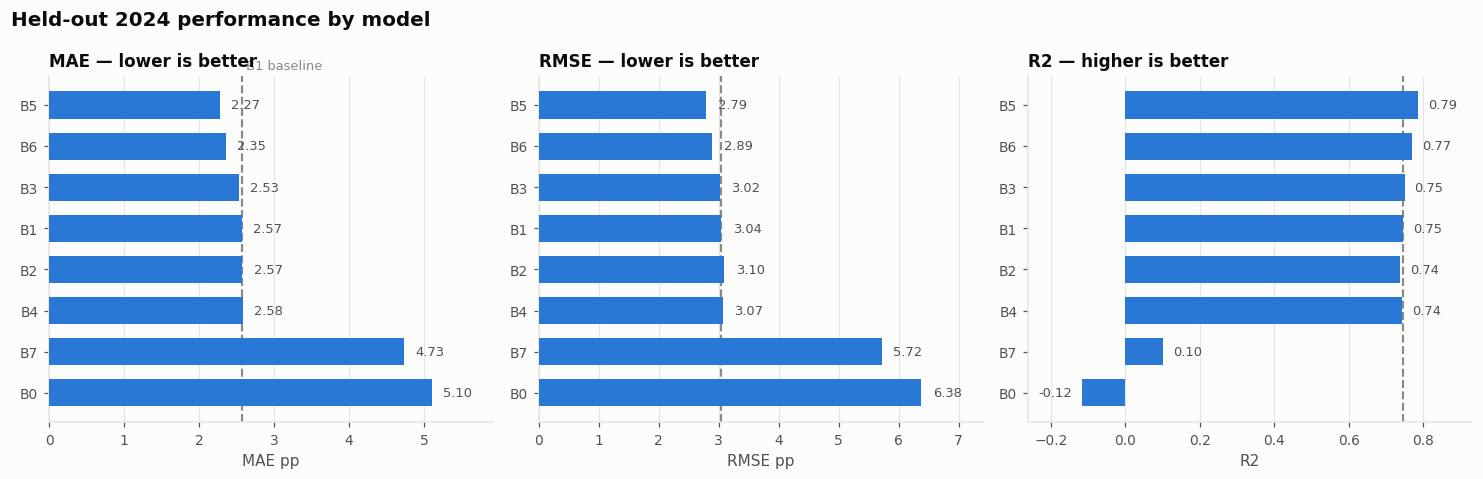

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
order = res.MAE.sort_values(ascending=False).index          # best model ends up on top

for ax, (metric, unit, better) in zip(axes, [("MAE", " pp", "lower"),
                                             ("RMSE", " pp", "lower"),
                                             ("R2", "", "higher")]):
    v = res.loc[order, metric]
    ax.barh(range(len(v)), v.values, height=0.66, color=BLUE, zorder=3)
    ax.axvline(res.loc[B1, metric], color=MUTED, ls="--", lw=1.4, zorder=2)   # baseline ref
    ax.set_yticks(range(len(v)), [s.split("  ")[0] for s in v.index])
    pad = (v.max() - min(v.min(), 0)) * 0.03
    for i, x in enumerate(v.values):
        ax.text(x + pad if x >= 0 else x - pad, i, f"{x:.2f}", va="center",
                ha="left" if x >= 0 else "right", fontsize=8.5, color=INK2)
    ax.set_title(f"{metric} — {better} is better", loc="left")
    ax.set_xlabel(metric + unit)
    ax.margins(x=0.16)
    clean(ax, grid_axis="x")

axes[0].text(res.loc[B1, "MAE"], len(order) - 0.2, " B1 baseline",
             fontsize=8.5, color=MUTED, va="bottom")
fig.suptitle("Held-out 2024 performance by model", x=0.005, ha="left",
             fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

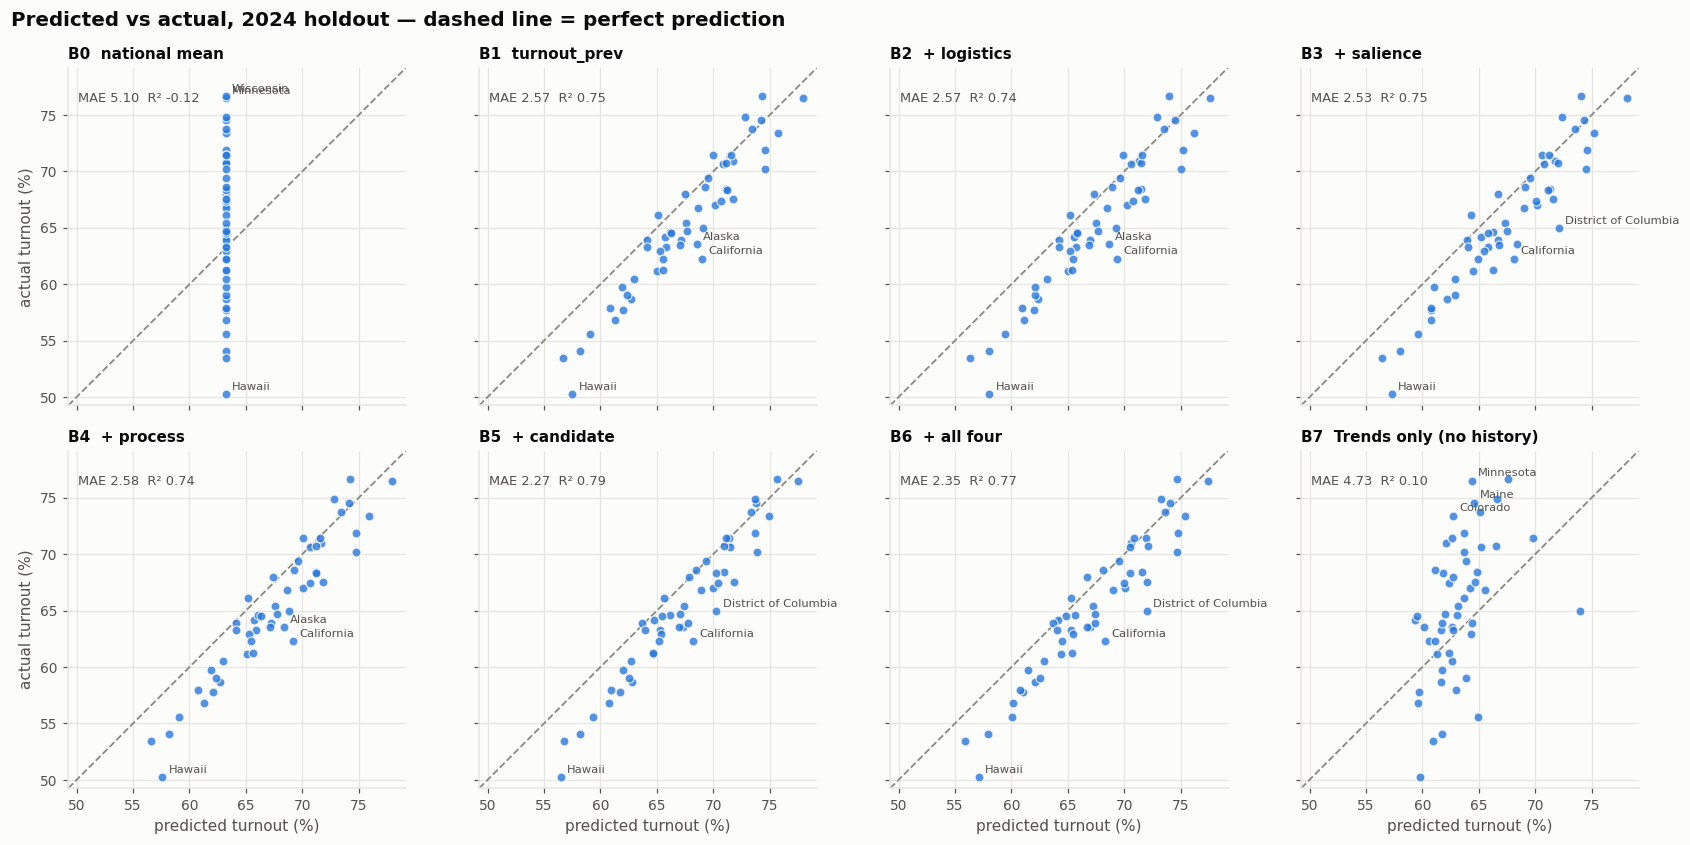

In [ ]:
names = list(MODELS)
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.8), sharex=True, sharey=True)
lo = min(P.turnout.min(), P[names].values.min()) - 1
hi = max(P.turnout.max(), P[names].values.max()) + 1

for ax, name in zip(axes.ravel(), names):
    resid = P.turnout - P[name]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls="--", lw=1.2, zorder=2)   # perfect fit
    ax.scatter(P[name], P.turnout, s=34, color=BLUE, alpha=.8,
               edgecolor=SURF, linewidth=.8, zorder=3)
    for i in resid.abs().nlargest(3).index:                                # label worst 3 only
        ax.annotate(P.state[i], (P[name][i], P.turnout[i]), fontsize=7.5,
                    color=INK2, xytext=(4, 3), textcoords="offset points")
    ax.set_title(name, loc="left", fontsize=10)
    ax.text(.03, .93, f"MAE {res.loc[name,'MAE']:.2f}  R² {res.loc[name,'R2']:.2f}",
            transform=ax.transAxes, fontsize=8.5, color=INK2, va="top")
    ax.set_aspect("equal"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    clean(ax, grid_axis="both")

for ax in axes[:, 0]: ax.set_ylabel("actual turnout (%)")
for ax in axes[-1, :]: ax.set_xlabel("predicted turnout (%)")
fig.suptitle("Predicted vs actual, 2024 holdout — dashed line = perfect prediction",
             x=0.005, ha="left", fontsize=13, fontweight="semibold", color=INK)
plt.tight_layout(); plt.show()

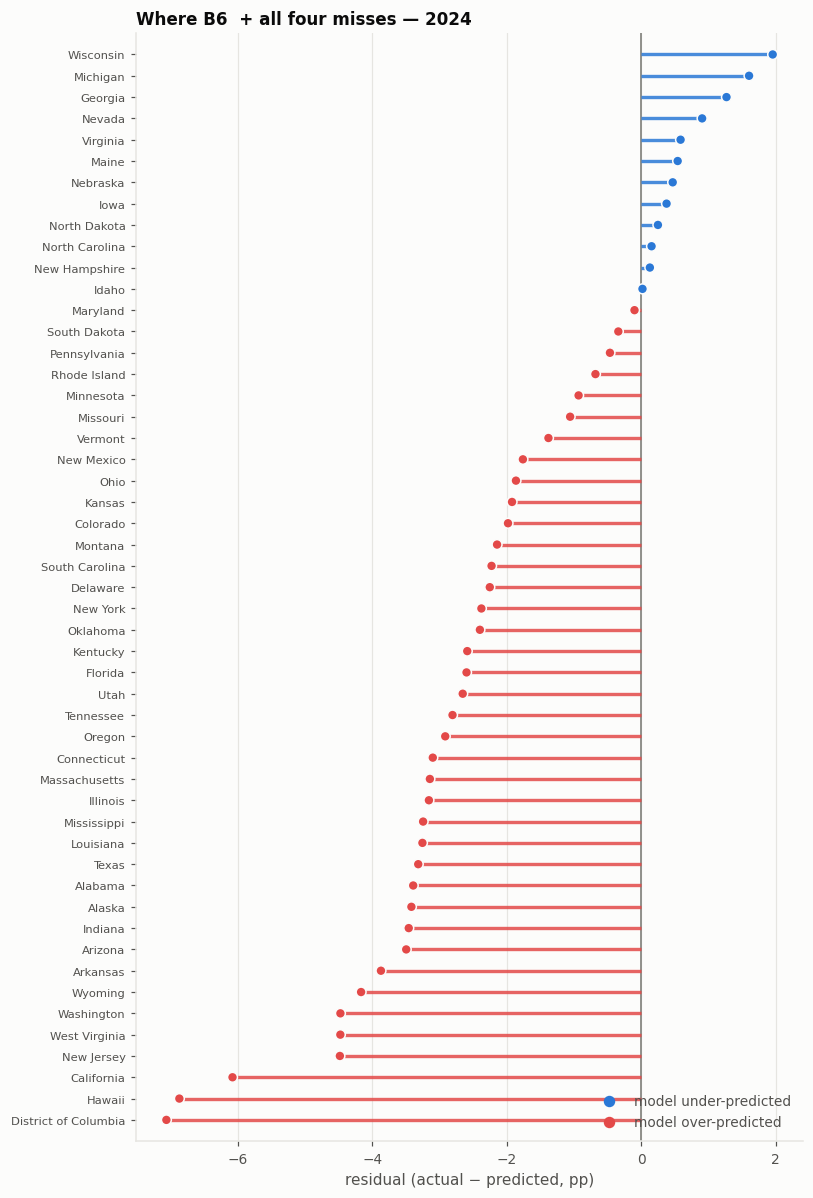

In [ ]:
PICK = "B5  + candidate"   # two spaces after B5 — must match the MODELS key
best = res.MAE.drop(["B0  national mean", "B7  Trends only (no history)"]).idxmin()
if best != PICK:
    print(f"heads up: best model by MAE is now '{best.strip()}', not '{PICK.strip()}'")
r = (P.turnout - P[PICK]).rename("resid")
d = P[["state"]].join(r).sort_values("resid")

fig, ax = plt.subplots(figsize=(7.5, 11))
colors = np.where(d.resid >= 0, BLUE, RED)
ax.hlines(range(len(d)), 0, d.resid, color=colors, lw=2.2, alpha=.85, zorder=3)
ax.scatter(d.resid, range(len(d)), s=42, color=colors,
           edgecolor=SURF, linewidth=1, zorder=4)
ax.axvline(0, color=MUTED, lw=1.2, zorder=2)
ax.set_yticks(range(len(d)), d.state, fontsize=7.5)
ax.set_ylim(-1, len(d)); ax.set_xlabel("residual (actual − predicted, pp)")
ax.set_title(f"Where {PICK.strip()} misses — 2024", loc="left")
ax.scatter([], [], s=42, color=BLUE, label="model under-predicted")
ax.scatter([], [], s=42, color=RED,  label="model over-predicted")
ax.legend(loc="lower right", fontsize=9, labelcolor=INK2)
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()

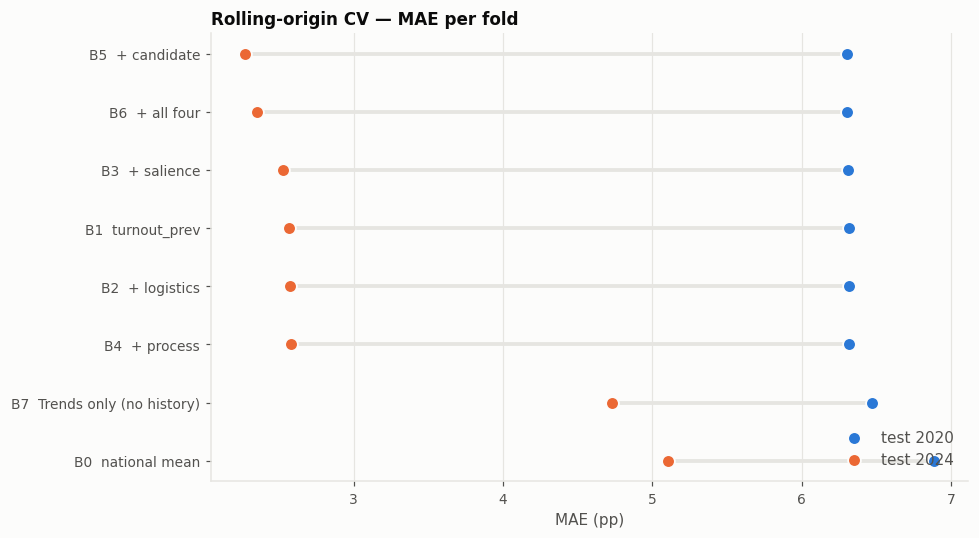

In [ ]:
cv = {}
for train_years, test_year in FOLDS:
    trf = model_df[model_df.year.isin(train_years)]
    tef = model_df[model_df.year == test_year]
    cv[f"test {test_year}"] = [
        scores(tef.turnout.values,
               np.full(len(tef), trf.turnout.mean()) if not cols
               else predict(fit_ols(trf[cols].values, trf.turnout.values), tef[cols].values)
              )["MAE"]
        for cols in MODELS.values()]
cv = pd.DataFrame(cv, index=list(MODELS))
cv["mean"] = cv.mean(axis=1)

o = cv["mean"].sort_values(ascending=False).index
f1, f2 = cv.columns[0], cv.columns[1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.hlines(range(len(o)), cv.loc[o, f1], cv.loc[o, f2], color=GRID, lw=2.5, zorder=2)
ax.scatter(cv.loc[o, f1], range(len(o)), s=70, color=BLUE,   label=f1,
           edgecolor=SURF, lw=1.2, zorder=3)
ax.scatter(cv.loc[o, f2], range(len(o)), s=70, color=ORANGE, label=f2,
           edgecolor=SURF, lw=1.2, zorder=3)
ax.set_yticks(range(len(o)), o, fontsize=9)
ax.set_xlabel("MAE (pp)"); ax.legend(loc="lower right", labelcolor=INK2)
ax.set_title("Rolling-origin CV — MAE per fold", loc="left")
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()

baseline test MAE = 2.425 pp


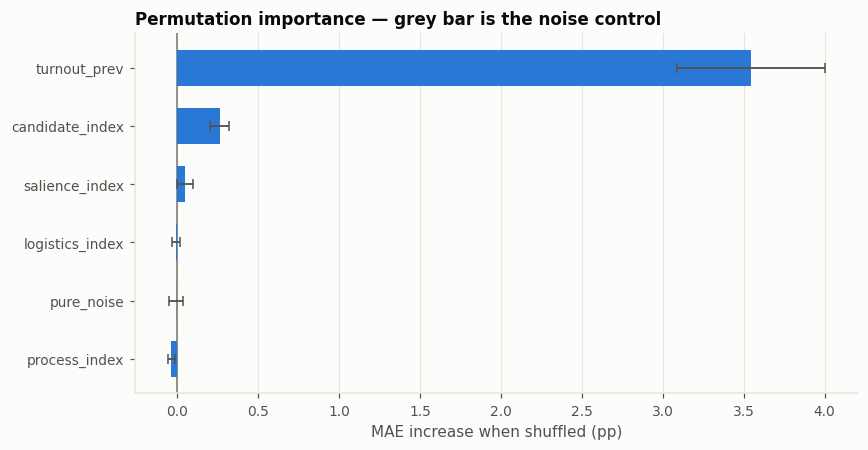

In [ ]:
rng   = np.random.default_rng(0)
trp   = model_df[model_df.year <  2024].copy()
tep   = model_df[model_df.year == 2024].copy()
trp["pure_noise"] = rng.normal(size=len(trp))
tep["pure_noise"] = rng.normal(size=len(tep))
COLS  = FEATS + ["pure_noise"]

coef       = fit_ols(trp[COLS].values, trp.turnout.values)
X_te, y_te = tep[COLS].values, tep.turnout.values
base_mae   = np.abs(y_te - predict(coef, X_te)).mean()
print(f"baseline test MAE = {base_mae:.3f} pp")

rows = []
for i, f in enumerate(COLS):
    ds = []
    for _ in range(100):
        Xp = X_te.copy()
        Xp[:, i] = rng.permutation(Xp[:, i])
        ds.append(np.abs(y_te - predict(coef, Xp)).mean() - base_mae)
    rows.append(dict(feature=f, rise=np.mean(ds), sd=np.std(ds)))
imp = pd.DataFrame(rows).sort_values("rise")

fig, ax = plt.subplots(figsize=(8, 4.2))
cols_ = [MUTED if f == "pure_noise" else BLUE for f in imp.feature]
ax.barh(imp.feature, imp.rise, xerr=imp.sd, height=0.62, color=cols_,
        error_kw=dict(ecolor=INK2, lw=1.2, capsize=3), zorder=3)
ax.axvline(0, color=MUTED, lw=1.2, zorder=2)
ax.set_xlabel("MAE increase when shuffled (pp)")
ax.set_title("Permutation importance — grey bar is the noise control", loc="left")
clean(ax, grid_axis="x")
plt.tight_layout(); plt.show()